In [1]:
# this file to get data from mongoDB
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi
from dotenv import load_dotenv
import os
import json

In [2]:
# to get environment vars
load_dotenv()

True

In [3]:
# connect to the database
uri = os.getenv('MONGODB_CONNECTION_STRING')
client = MongoClient(uri, server_api=ServerApi('1'))

In [4]:
# Send a ping to confirm a successful connection
try:
  print("You successfully connected to MongoDB!")
except Exception as e:
  print(e)

You successfully connected to MongoDB!


In [5]:
db = client['Hotel'] # access database
collection = db['Hotel'] # access collection in a database

In [6]:
# create index on city field for faster querying
# collection.create_index({'city': 1})

# another one for title as it is queried frequently
# collection.create_index({'title': 1})

In [7]:
from bson.objectid import ObjectId

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go

### Getting data for wordCloud

In [9]:
# get and concat all comments description
data1 = collection.aggregate([{
  '$project': {
    'comments.description': 1, 
    'rating': 1,
    '_id': 0,
  },
}])

In [10]:
# print fetched data
text = ""
for obj in data1:
  for desc in obj['comments']:
    text += desc['description']
text

"We had a lovely stay at Serry Beach Resort. The property is beautiful, with a stunning pool and beach that made for the perfect relaxation spot. The atmosphere was peaceful, and the staff were friendly and welcoming. We truly enjoyed our time here...The service was top, and everyone was happy and friendly.\nFatima at the reception went out of her to see that we get the best room.\nThere was a variety of food dishes, so many options to choose. The best part was late breakfast and lunch for those...I loved how clean this property was, the great food, the accommodating staff, the entertainment timetable, the large single beds that could comfortably fit in two people, the clean beach, the view from my room… I could go on and onAmazing location at the beach with beautiful long pool and sun chairs. Breakfast offers large variety and is tasty.One of the best resorts in Hurghada recommend it to everyone going thereIt was clean, beautiful, scenic, peaceful, aesthetic, vibes were immaculate and

In [11]:
len(text)

243910

In [12]:
import nltk

In [13]:
# nltk.download('stopwords')

In [14]:
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))

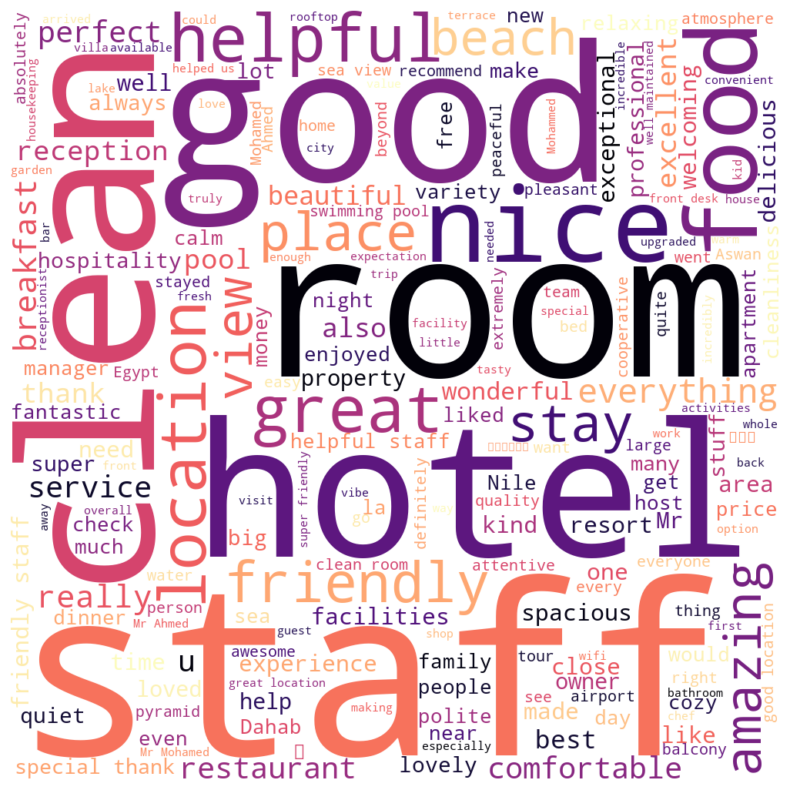

In [15]:
cloud = WordCloud(width=1000, height=1000, stopwords=stops, background_color='white', colormap='magma').generate(text)

plt.figure(figsize=(8, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
data2 = list(collection.aggregate([
  {
  '$match': {
    'city': {
        '$exists': True,
        '$ne': None
      }
    },
  },{
  '$group': {
    '_id': '$city', 
    'count': {
      '$sum': 1
    },
    'avg_rating': {
      '$avg': {
        '$ifNull': ['$rating', 0]
      }
    },
    'avg_price': {
      '$avg': {
        '$ifNull': ['$price', 0]
      }
    },
    'latitude': {
      '$avg': {
        '$ifNull': ['$latitude', 0]
      }
    },
    'longitude': {
      '$avg': {
        '$ifNull': ['$longitude', 0]
      }
    },
  },
}]))

In [17]:
for obj in data2:
  print(obj)

{'_id': 'Ismailia', 'count': 15, 'avg_rating': 4.6066666666666665, 'avg_price': 1958.6666666666667, 'latitude': 30.57893314520411, 'longitude': 32.26821127187109}
{'_id': 'Aswan', 'count': 25, 'avg_rating': 8.092, 'avg_price': 512.32, 'latitude': 24.089226775766093, 'longitude': 32.882503765847844}
{'_id': 'Hurghada', 'count': 31, 'avg_rating': 6.867741935483871, 'avg_price': 519.3225806451613, 'latitude': 27.6837049071689, 'longitude': 33.54326616436688}
{'_id': 'Marsa Alam', 'count': 22, 'avg_rating': 9.004545454545454, 'avg_price': 548.0909090909091, 'latitude': 25.231095092333693, 'longitude': 34.8007862526018}
{'_id': 'Dahab', 'count': 24, 'avg_rating': 8.25, 'avg_price': 326.5833333333333, 'latitude': 28.49722488437615, 'longitude': 34.51161868407057}
{'_id': 'North Coast', 'count': 3, 'avg_rating': 9.166666666666666, 'avg_price': 462.0, 'latitude': 30.962679019288046, 'longitude': 28.507248818801813}
{'_id': 'Port Said', 'count': 25, 'avg_rating': 6.843999999999999, 'avg_price':

In [18]:
import plotly.express as px
df = pd.DataFrame(data2)
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="_id",
    size="count",      
    color="avg_rating",
    color_continuous_scale="Viridis",
    zoom=5,
    height=600,
    title="Egypt Cities: Avg Rating by Count"
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

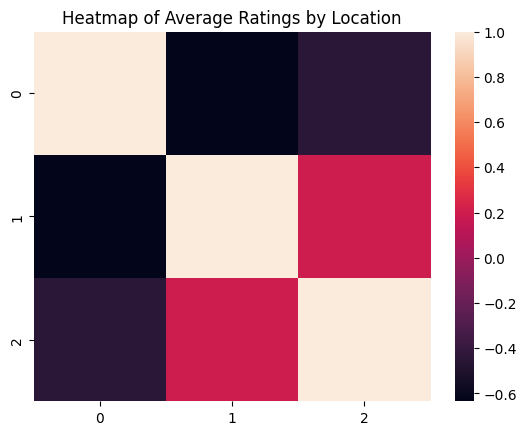

In [19]:
###Yahya
heat_data = [[item['latitude'], item['longitude'], item['avg_rating']] for item in data2]
heat_data=pd.DataFrame(heat_data)
heat_data=heat_data.corr()
sns.heatmap(heat_data)
plt.title('Heatmap of Average Ratings by Location')
plt.show()

In [20]:
cities = [doc['_id'] for doc in data2]
counts = [doc['count'] for doc in data2]

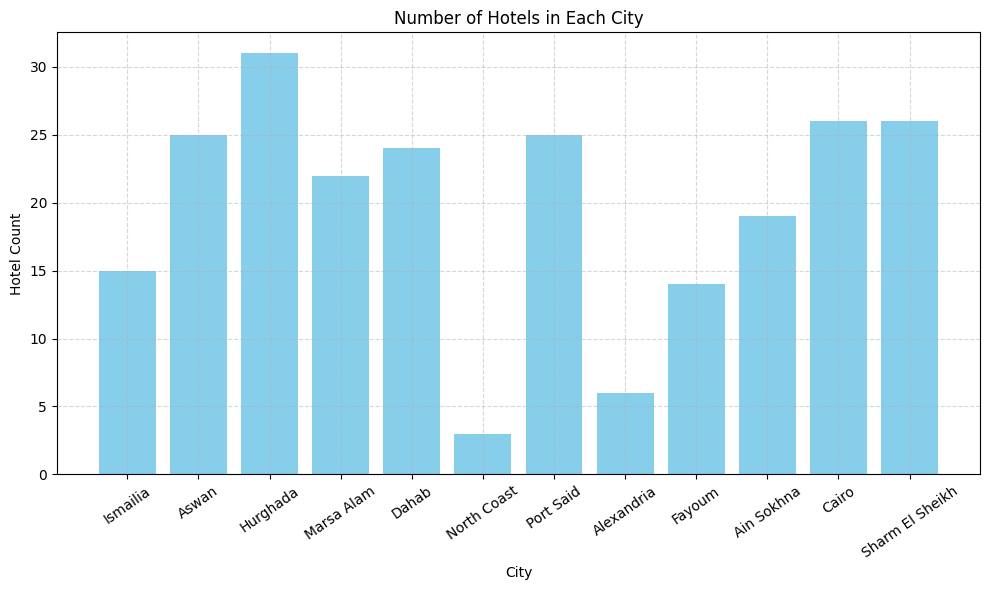

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(cities, counts, color='skyblue')
plt.title('Number of Hotels in Each City')
plt.xlabel('City')
plt.ylabel('Hotel Count')
plt.xticks(rotation=35)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
data3 = list(collection.aggregate([
  {'$unwind': '$facilities'}, # deconstruct array elements
  {
    '$group': {
      '_id': '$facilities',
      'count': {
        '$sum': 1
      },
      'avg_rating': {
        '$avg': {
          '$ifNull': ['$rating', 0]
        }
      },
      'avg_price': {
        '$avg': {
          '$ifNull': ['$price', 0]
        } 
      }
    }
  }
]))

In [23]:
for obj in data3:
  print(obj)

{'_id': '2 restaurants', 'count': 18, 'avg_rating': 7.811111111111111, 'avg_price': 299.6111111111111}
{'_id': 'Free parking', 'count': 174, 'avg_rating': 6.9045977011494255, 'avg_price': 675.3735632183908}
{'_id': 'Swimming pool', 'count': 7, 'avg_rating': 1.5, 'avg_price': 237.57142857142858}
{'_id': 'Excellent Breakfast', 'count': 15, 'avg_rating': 8.78, 'avg_price': 643.6666666666666}
{'_id': 'Very Good Breakfast', 'count': 28, 'avg_rating': 8.325, 'avg_price': 795.4285714285714}
{'_id': '9 swimming pools', 'count': 3, 'avg_rating': 6.566666666666667, 'avg_price': 0.0}
{'_id': 'Fitness center', 'count': 63, 'avg_rating': 7.850793650793651, 'avg_price': 954.2698412698413}
{'_id': '3 swimming pools', 'count': 16, 'avg_rating': 8.3125, 'avg_price': 423.25}
{'_id': 'Family rooms', 'count': 161, 'avg_rating': 7.3105590062111805, 'avg_price': 571.4534161490683}
{'_id': 'Wifi', 'count': 4, 'avg_rating': 6.75, 'avg_price': 410.75}
{'_id': 'Breakfast', 'count': 84, 'avg_rating': 6.85, 'avg_

In [24]:
all = sorted(data3, key=lambda x: x['count'], reverse=True)
tops = all[:10]

facilities = [doc["_id"] for doc in tops]
counts = [doc["count"] for doc in tops]
rating = [doc["avg_rating"] for doc in tops]

In [25]:
x = np.arange(len(facilities))
width = 0.35

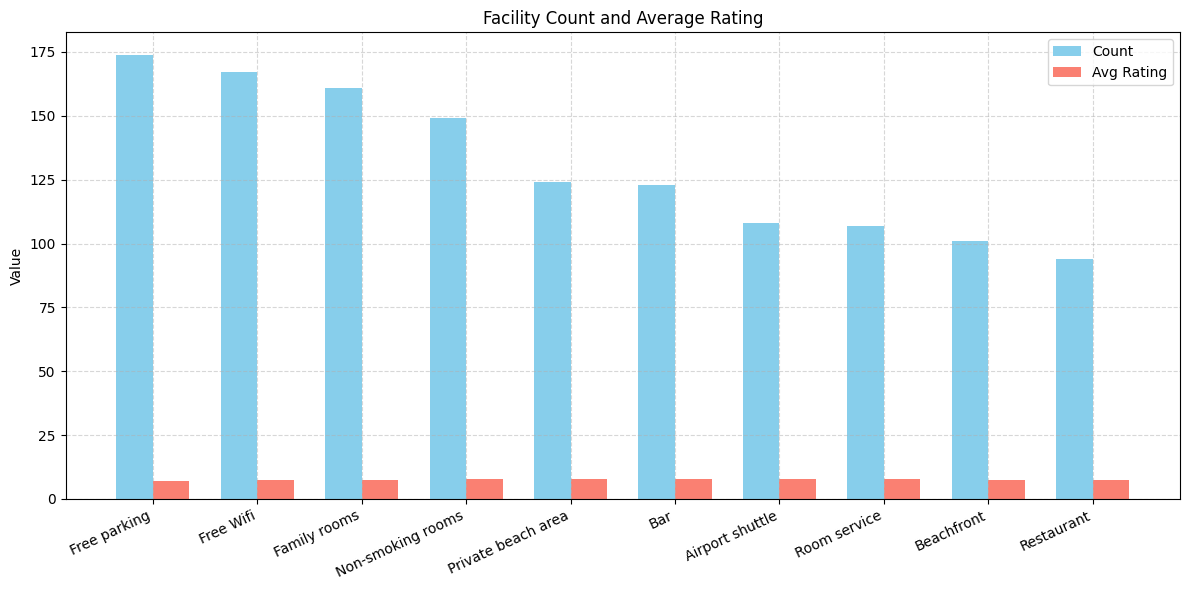

In [26]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, counts, width, label='Count', color='skyblue')
bars2 = ax.bar(x + width/2, rating, width, label='Avg Rating', color='salmon')

# Labels and formatting
ax.set_ylabel('Value')
ax.set_title('Facility Count and Average Rating')
ax.set_xticks(x)
ax.set_xticklabels(facilities, rotation=25, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

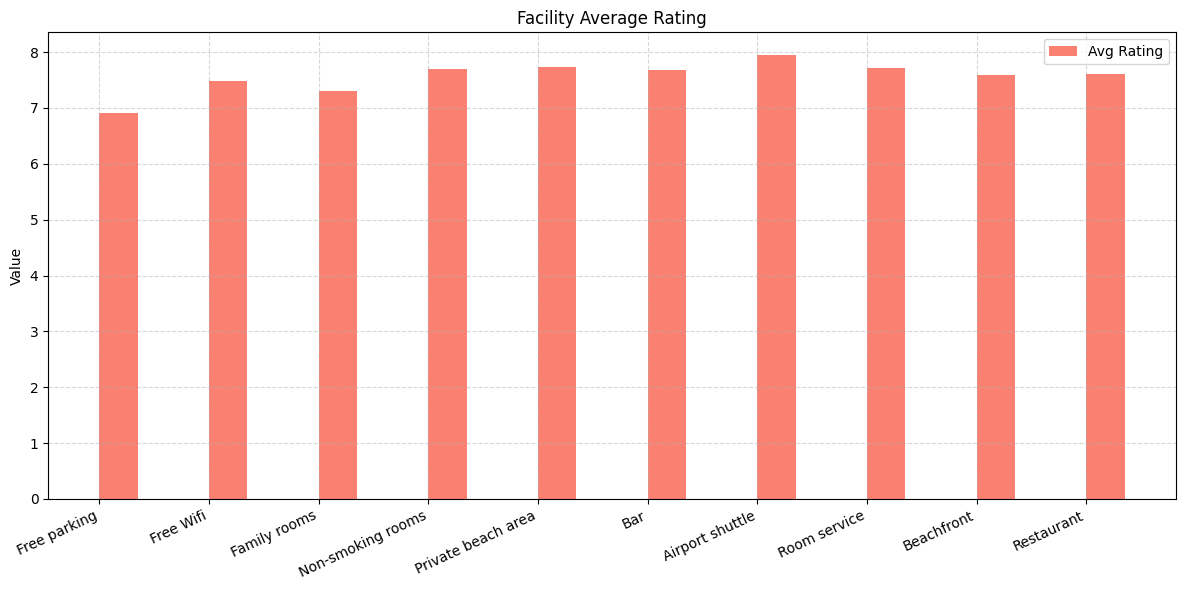

In [27]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars2 = ax.bar(x + width/2, rating, width, label='Avg Rating', color='salmon')

# Labels and formatting
ax.set_ylabel('Value')
ax.set_title('Facility Average Rating')
ax.set_xticks(x)
ax.set_xticklabels(facilities, rotation=25, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Frequency of facilities')

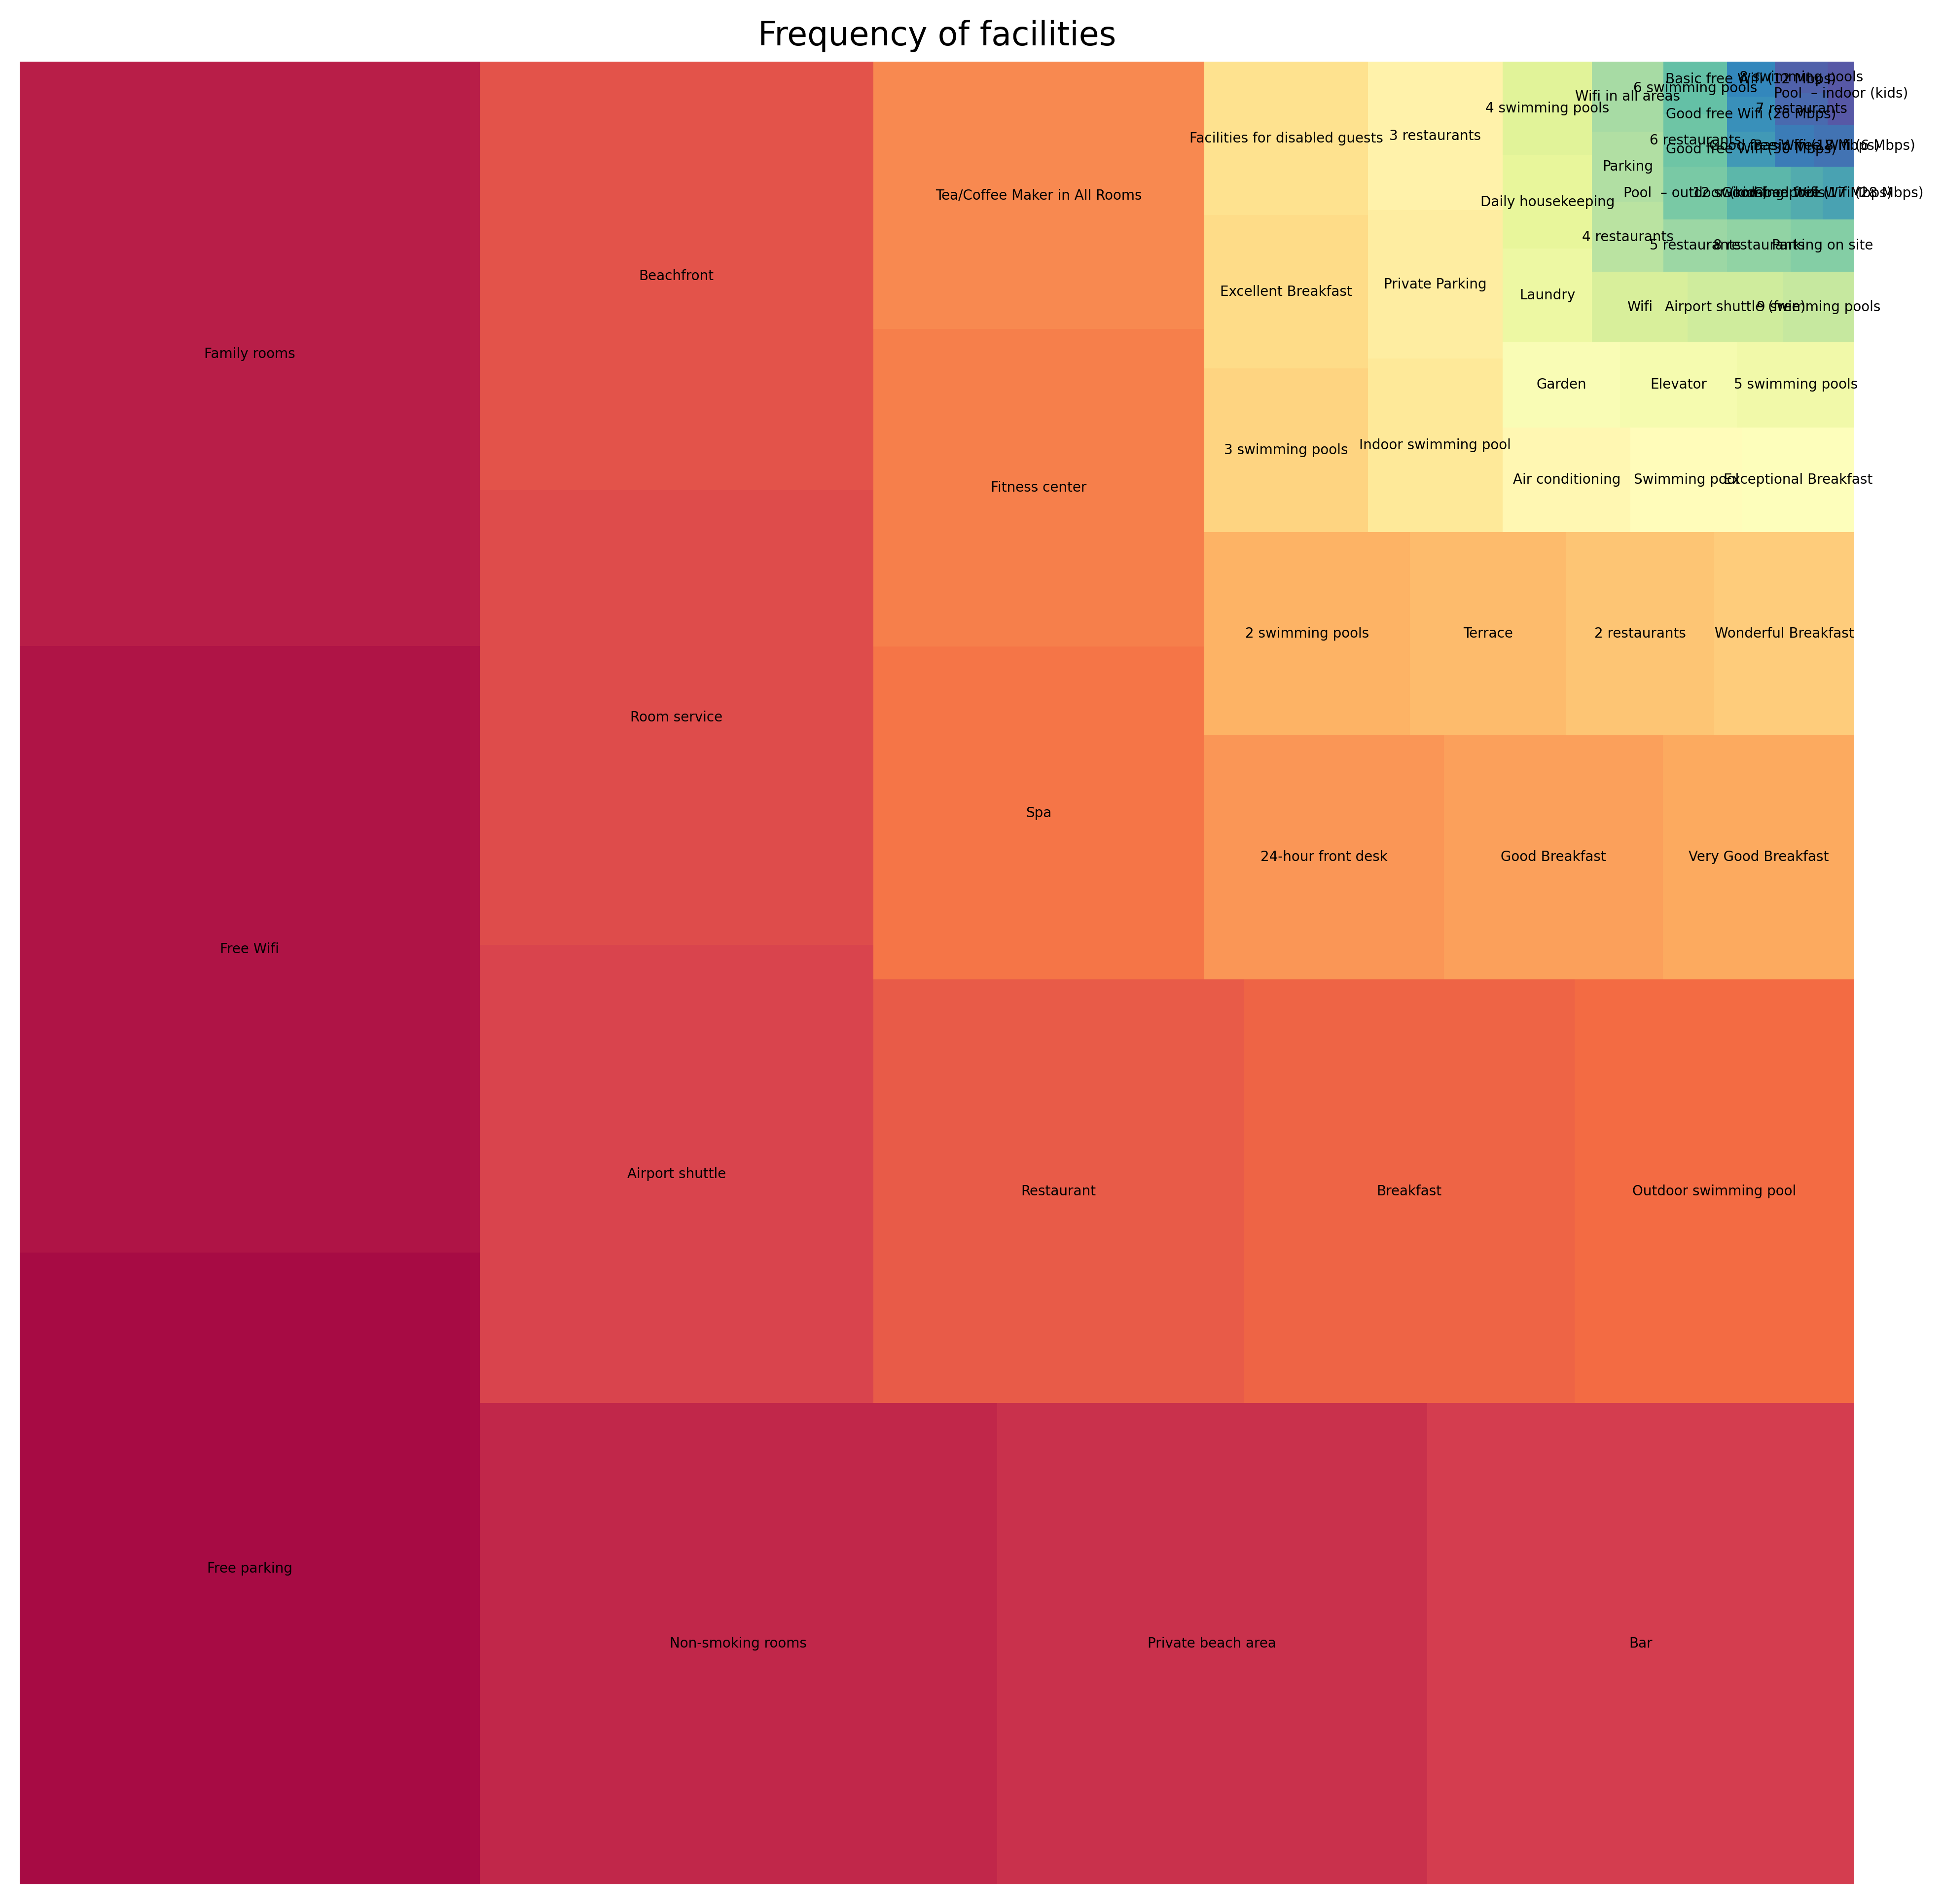

In [28]:
import squarify

plt.figure(figsize=(12, 12), dpi=400)

facilities = np.array([doc["_id"] for doc in all])
counts = np.array([doc["count"] for doc in all])
rating = np.array([doc["avg_rating"] for doc in all])

df = pd.DataFrame({
  'name': facilities,
  'count': counts,
  'rating': rating
})

df.sort_values(by='count')
squarify.plot(sizes=df['count'], label=df['name'], 
              color=sns.color_palette("Spectral", len(df)),
              text_kwargs={'fontsize': 5},
              )
plt.axis('off')
plt.title("Frequency of facilities")

In [29]:
data4 = list(collection.aggregate([
  {
    '$match': {
      'rating': {
        '$exists': True,
        '$ne': None
      }
    }
  },
  {'$project': {
      'rating_details': 1,
      'title': 1,
      '_id': 0,
      'rating': 1
    }
  },
]))

In [30]:
for obj in data4:
  print(obj)

{'title': 'Serry Beach Resort', 'rating': 8.8, 'rating_details': {'Staff': 8.8, 'Facilities': 9.0, 'Cleanliness': 9.2, 'Comfort': 9.2, 'Value for money': 8.3, 'Location': 9.3, 'Free Wifi': 9.4}}
{'title': 'Andalusia Blue Beach Hurghada', 'rating': 7.5, 'rating_details': {'Staff': 8.4, 'Facilities': 7.2, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 8.1, 'Location': 8.8, 'Free Wifi': 5.6}}
{'title': 'Elaria Hotel Hurgada', 'rating': 7.4, 'rating_details': {'Staff': 8.6, 'Facilities': 7.3, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 7.9, 'Location': 8.2, 'Free Wifi': 9.2}}
{'title': 'Royal City Hotel', 'rating': 6.6, 'rating_details': {'Staff': 7.5, 'Facilities': 6.5, 'Cleanliness': 6.7, 'Comfort': 7.2, 'Value for money': 7.2, 'Location': 8.4, 'Free Wifi': 3.2}}
{'title': 'Juliana Beach Resort by VISION HURGHADA', 'rating': 6.6, 'rating_details': {'Staff': 7.7, 'Facilities': 7.0, 'Cleanliness': 6.7, 'Comfort': 7.0, 'Value for money': 7.0, 'Location': 6.9}}
{'title': '

In [31]:
hotels = [h for h in data4 if h.get("rating_details") and len(h["rating_details"]) > 0]
print(hotels)

[{'title': 'Serry Beach Resort', 'rating': 8.8, 'rating_details': {'Staff': 8.8, 'Facilities': 9.0, 'Cleanliness': 9.2, 'Comfort': 9.2, 'Value for money': 8.3, 'Location': 9.3, 'Free Wifi': 9.4}}, {'title': 'Andalusia Blue Beach Hurghada', 'rating': 7.5, 'rating_details': {'Staff': 8.4, 'Facilities': 7.2, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 8.1, 'Location': 8.8, 'Free Wifi': 5.6}}, {'title': 'Elaria Hotel Hurgada', 'rating': 7.4, 'rating_details': {'Staff': 8.6, 'Facilities': 7.3, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 7.9, 'Location': 8.2, 'Free Wifi': 9.2}}, {'title': 'Royal City Hotel', 'rating': 6.6, 'rating_details': {'Staff': 7.5, 'Facilities': 6.5, 'Cleanliness': 6.7, 'Comfort': 7.2, 'Value for money': 7.2, 'Location': 8.4, 'Free Wifi': 3.2}}, {'title': 'Juliana Beach Resort by VISION HURGHADA', 'rating': 6.6, 'rating_details': {'Staff': 7.7, 'Facilities': 7.0, 'Cleanliness': 6.7, 'Comfort': 7.0, 'Value for money': 7.0, 'Location': 6.9}}, {'tit

In [32]:
# Sort by rating
hotels_sorted = sorted(hotels, key=lambda x: x["rating"])

# Get lowest and highest rated hotels
lowest_rated = hotels_sorted[0]
highest_rated = hotels_sorted[-1]

In [33]:
print(lowest_rated)
print(highest_rated)

{'title': 'Toka', 'rating': 1.0, 'rating_details': {'Staff': 2.5, 'Facilities': 2.5, 'Cleanliness': 2.5, 'Comfort': 2.5, 'Value for money': 2.5, 'Location': 2.5}}
{'title': 'شاليه الهنا 1 للإيجار مصيف قرية النورس الإسماعيلية', 'rating': 10.0, 'rating_details': {'Staff': 10.0, 'Facilities': 10.0, 'Cleanliness': 10.0, 'Comfort': 10.0, 'Value for money': 10.0, 'Location': 10.0}}


In [34]:
#pip install arabic-reshaper python-bidi

In [35]:
metrics = list(highest_rated["rating_details"].keys())
num_metrics = len(metrics)

In [36]:
print(metrics)

['Staff', 'Facilities', 'Cleanliness', 'Comfort', 'Value for money', 'Location']


In [37]:
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()    # (start, stop, angle per metric)
angles += angles[:1]  # complete the circle by adding the first element as the last angle

In [38]:
print(angles)

[0.0, 1.0471975511965976, 2.0943951023931953, 3.141592653589793, 4.1887902047863905, 5.235987755982988, 0.0]


In [39]:
import arabic_reshaper
from bidi.algorithm import get_display

def reshape_arabic(text):
    try:
        reshaped = arabic_reshaper.reshape(text)
        return get_display(reshaped)
    except:
        return text

In [40]:
hotels=[lowest_rated,highest_rated]
#colors=['salmon','seagreen']
colors=['#1f77b4','#ff7f0e']

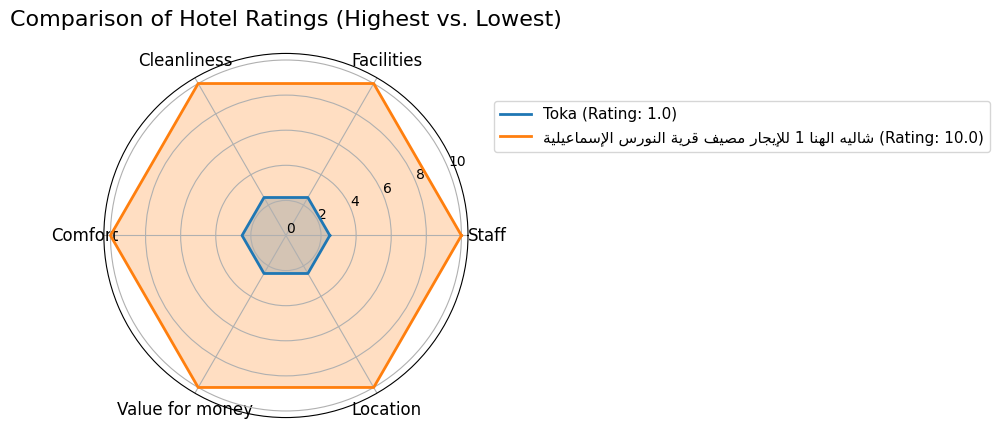

In [41]:
plt.figure(figsize=(9, 8))
ax = plt.subplot(111, polar=True)

##################################

for hotel, color in zip(hotels,colors):
    values = list(hotel["rating_details"].values())
    values += values[:1]
    title = reshape_arabic(hotel['title'])
    ax.plot(angles, values, label=f"{title} (Rating: {hotel['rating']})", linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)

##################################
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticks(np.arange(0, 11, 2))
ax.set_yticklabels(map(str, np.arange(0, 11, 2)), fontsize=10)
plt.title("Comparison of Hotel Ratings (Highest vs. Lowest)", size=16, pad=20)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.8), fontsize=11)
plt.tight_layout()
plt.show()

In [42]:
data5 = collection.aggregate([
  {
    '$group': {
      '_id': '$title',
      'avg_rating': {
        '$avg': {
          '$ifNull': ['$rating', 0]
        }
      },
      'avg_price': {
        '$avg': {
          '$ifNull': ['$price', 0]
        } 
      }
    }
  }
])

In [43]:
for obj in data5:
  print(obj)

{'_id': 'Holiday Inn fayoum', 'avg_rating': 7.8, 'avg_price': 0.0}
{'_id': 'The Boutique Hotel Hurghada Marina', 'avg_rating': 8.2, 'avg_price': 0.0}
{'_id': '4-BRS Entire FarmHouse in Ismailia lGreen Paradise', 'avg_rating': 0.0, 'avg_price': 0.0}
{'_id': 'Cleopatra Sidi Heneish', 'avg_rating': 9.4, 'avg_price': 0.0}
{'_id': 'Manzzel Dahab Hostel', 'avg_rating': 10.0, 'avg_price': 1039.0}
{'_id': 'Fayoum Hotel', 'avg_rating': 7.4, 'avg_price': 0.0}
{'_id': 'شقة خلف شارع طرح البحر عند عبده كفته307', 'avg_rating': 9.8, 'avg_price': 0.0}
{'_id': 'براديس الاحياء', 'avg_rating': 0.0, 'avg_price': 873.0}
{'_id': 'Gemma Resort', 'avg_rating': 9.8, 'avg_price': 0.0}
{'_id': 'Golden Europe Hotel', 'avg_rating': 7.2, 'avg_price': 0.0}
{'_id': 'Casa Do Cairo-Sharm Alsheikh', 'avg_rating': 9.3, 'avg_price': 0.0}
{'_id': 'Six Corners Resort', 'avg_rating': 8.4, 'avg_price': 0.0}
{'_id': 'Le Beau Site Chalet', 'avg_rating': 8.1, 'avg_price': 0.0}
{'_id': 'Tache Boutique Hotel Fayoum', 'avg_rating':

In [44]:
data6 = list(collection.aggregate([
  {'$unwind': '$comments'},
  {
    '$group': {
      '_id': '$comments.country',
      'count': {
        '$sum': 1
      }
    }
  },
  {
    '$match': {
      '_id': {
        '$regex': r'\w{2,}'
      }
    }
  },
  {
    '$sort': {
      'count': 1
    }
  }
]))

In [45]:
for obj in data6:
  print(obj)

{'_id': 'Greece', 'count': 1}
{'_id': 'Sudan', 'count': 1}
{'_id': 'Yemen', 'count': 1}
{'_id': 'Ecuador', 'count': 1}
{'_id': 'Norway', 'count': 1}
{'_id': 'Lebanon', 'count': 1}
{'_id': 'Estonia', 'count': 1}
{'_id': 'Moldova', 'count': 1}
{'_id': 'Trinidad and Tobago', 'count': 1}
{'_id': 'Malta', 'count': 1}
{'_id': 'Morocco', 'count': 1}
{'_id': 'Laos', 'count': 1}
{'_id': 'Tunisia', 'count': 1}
{'_id': 'Georgia', 'count': 1}
{'_id': 'Iraq', 'count': 1}
{'_id': 'Serbia', 'count': 1}
{'_id': 'Latvia', 'count': 1}
{'_id': 'Libya', 'count': 1}
{'_id': 'Finland', 'count': 1}
{'_id': 'Azerbaijan', 'count': 1}
{'_id': 'Costa Rica', 'count': 1}
{'_id': 'Brazil', 'count': 2}
{'_id': 'Nigeria', 'count': 2}
{'_id': 'Romania', 'count': 2}
{'_id': 'Vietnam', 'count': 2}
{'_id': 'Mexico', 'count': 2}
{'_id': 'Luxembourg', 'count': 2}
{'_id': 'Slovenia', 'count': 2}
{'_id': 'Armenia', 'count': 2}
{'_id': 'Algeria', 'count': 2}
{'_id': 'Philippines', 'count': 2}
{'_id': 'Chile', 'count': 2}
{'_i

In [46]:
### Yahya
max_count = -1
country_with_max_count = None

for entry in data6:
    if entry['count'] > max_count:
        max_count = entry['count']
        country_with_max_count = entry['_id']

print(f"The country which leaves the most reviews is {country_with_max_count} with a count of {max_count}.")

The country which leaves the most reviews is Egypt with a count of 712.


In [47]:
topcountry = sorted(data6, key=lambda x: x["count"],reverse=True)[:10]

In [48]:
country = [entry['_id'] for entry in topcountry]
count = [entry['count'] for entry in topcountry]

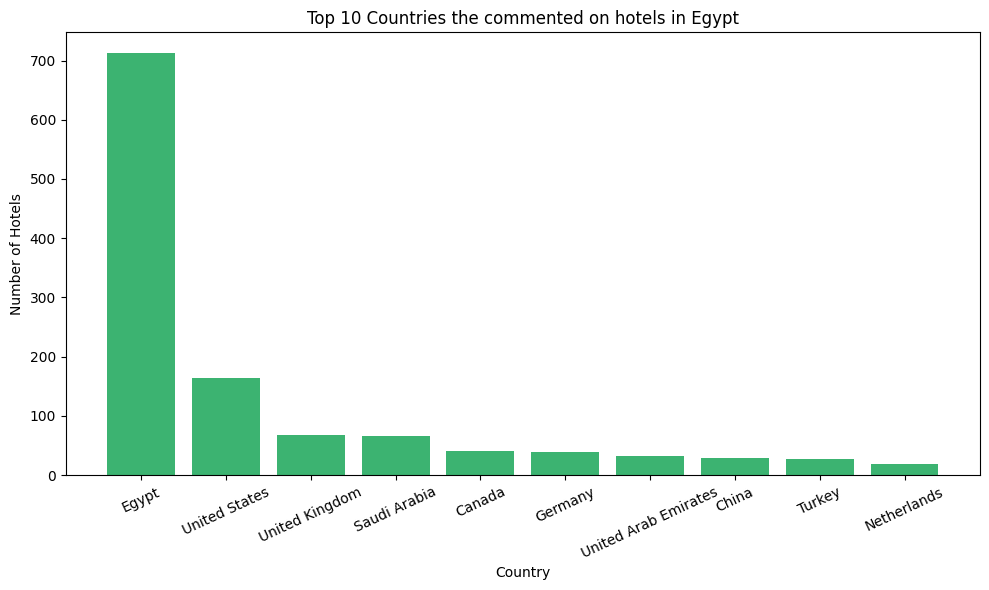

In [49]:
plt.figure(figsize=(10, 6))
plt.bar(country, count, color='mediumseagreen')
plt.title('Top 10 Countries the commented on hotels in Egypt')
plt.xlabel('Country')
plt.ylabel('Number of Hotels')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

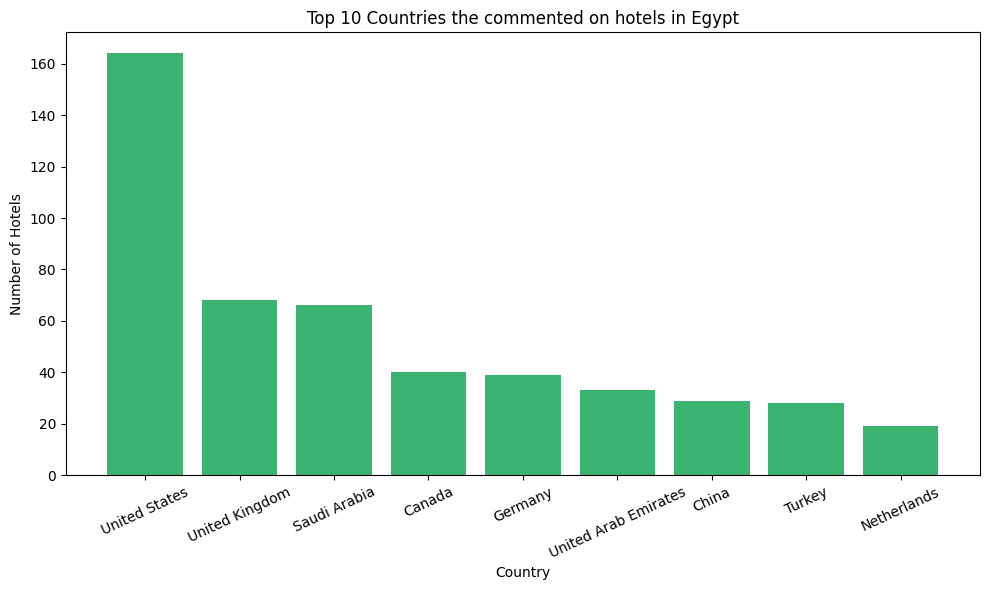

In [50]:
df = pd.DataFrame({
  'country': country,
  'count': count
})
df = df[df['country'] != "Egypt"]
plt.figure(figsize=(10, 6))
plt.bar(df['country'], df['count'], color='mediumseagreen')
plt.title('Top 10 Countries the commented on hotels in Egypt')
plt.xlabel('Country')
plt.ylabel('Number of Hotels')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [51]:
data7 = list(collection.aggregate([
  {
    '$match': {
      'price': {
        '$ne': None
      },
      'rating': {
        '$ne': None
      },
    }
  },
  {
    '$project': {
      '_id': 0,
      'rating': 1,
      'price': 1
    }
  }
]))

In [52]:
for obj in data7:
  print(obj)

{'price': 1294.0, 'rating': 8.8}
{'price': 1540.0, 'rating': 7.5}
{'price': 739.0, 'rating': 10.0}
{'price': 739.0, 'rating': 4.8}
{'price': 462.0, 'rating': 9.5}
{'price': 2070.0, 'rating': 8.9}
{'price': 3593.0, 'rating': 8.0}
{'price': 873.0, 'rating': 7.6}
{'price': 2160.0, 'rating': 8.8}
{'price': 2703.0, 'rating': 8.4}
{'price': 269.0, 'rating': 7.9}
{'price': 7562.0, 'rating': 7.4}
{'price': 4522.0, 'rating': 8.3}
{'price': 6086.0, 'rating': 7.7}
{'price': 5088.0, 'rating': 7.6}
{'price': 4517.0, 'rating': 7.7}
{'price': 2968.0, 'rating': 8.2}
{'price': 1039.0, 'rating': 10.0}
{'price': 982.0, 'rating': 8.0}
{'price': 1865.0, 'rating': 8.1}
{'price': 2207.0, 'rating': 6.8}
{'price': 1745.0, 'rating': 5.5}
{'price': 2309.0, 'rating': 7.5}
{'price': 3217.0, 'rating': 8.2}
{'price': 924.0, 'rating': 9.4}
{'price': 3945.0, 'rating': 7.3}
{'price': 2883.0, 'rating': 6.7}
{'price': 2515.0, 'rating': 8.2}
{'price': 581.0, 'rating': 7.6}
{'price': 924.0, 'rating': 8.4}
{'price': 1386.0,

In [53]:
prices = [entry['price'] for entry in data7]
ratings = [entry['rating'] for entry in data7]

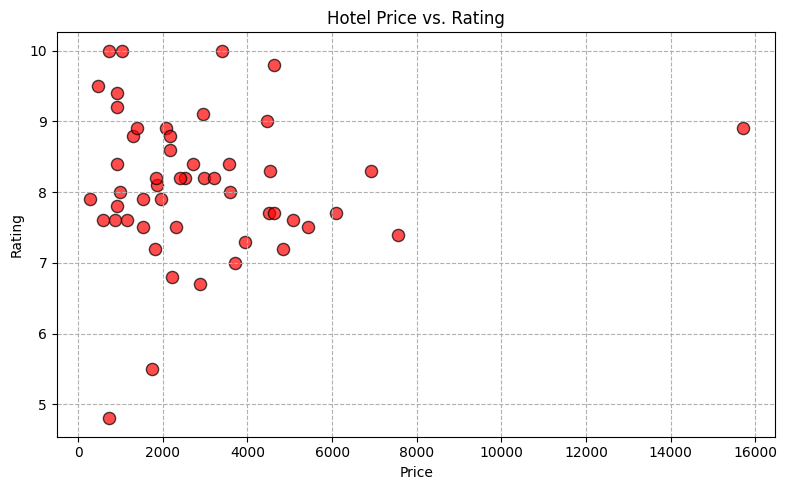

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(prices, ratings, color='red', edgecolor='black', s=77, alpha=0.7)

plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Hotel Price vs. Rating')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [55]:
# to close this connection as Free clusters are limited
# client.close()

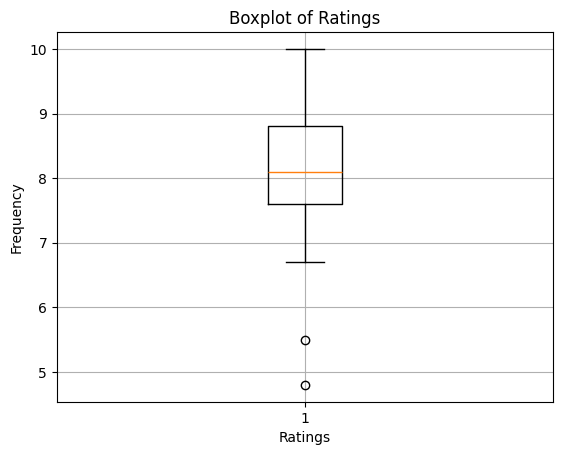

In [56]:
### Yahya
plt.boxplot(ratings)
plt.title("Boxplot of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

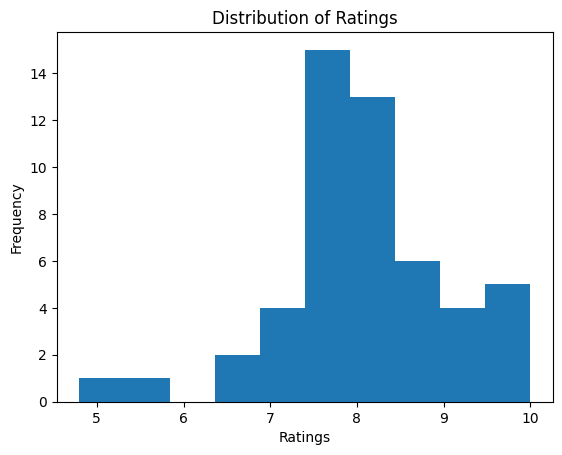

In [57]:
### Yahya
plt.hist(ratings)
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()